# WP1 - Data Ingestion and Structural Review
•	Parse metadata and reports from the CT-RATE dataset

•	Identify relevant fields for clinician retrieval (patient details, report free-text, study info)


Goal: load the CT-RATE dataset, understand its structure, and prepare a combined dataset for downstream analysis in WP2 and WP3.

CT-RATE consists of three parts:
- **reports**: free-text radiology reports (findings + impressions)
- **metadata**: technical scan parameters and patient demographics
- **labels**: automatically extracted abnormality labels

In [ ]:
# Imports 

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import os
from huggingface_hub import login


# Login with HuggingFace token

HF_TOKEN = os.environ.get("HF_TOKEN", " ")
login(token=HF_TOKEN)

DATASET_NAME = "ibrahimhamamci/CT-RATE"
OUTPUT_DIR = "../data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

### Loading the Dataset

CT-RATE dataset is hosted on HuggingFace

Note:
load all three subsets separately 
they can be merged later

In [2]:
#Load the three sub-sets individually

metadata_dataset = load_dataset(DATASET_NAME, "metadata", token=HF_TOKEN)
reports_dataset  = load_dataset(DATASET_NAME, "reports",  token=HF_TOKEN)
labels_dataset   = load_dataset(DATASET_NAME, "labels",   token=HF_TOKEN)



# check size of data 
print(f"Reports:  {len(reports_dataset['train'])} train; {len(reports_dataset['validation'])} validation")
print(f"Metadata: {len(metadata_dataset['train'])} train; {len(metadata_dataset['validation'])} validation")
print(f"Labels:   {len(labels_dataset['train'])} train; {len(labels_dataset['validation'])} validation")

Reports:  47149 train; 3039 validation
Metadata: 47149 train; 3039 validation
Labels:   47149 train; 3039 validation


## Converting to DataFrames

Convert data to Pandas Dataframes (only the training data)
Check the shape of the data

In [3]:
# convert to df 
df_reports  = pd.DataFrame(reports_dataset['train'])
df_metadata = pd.DataFrame(metadata_dataset['train'])
df_labels   = pd.DataFrame(labels_dataset['train'])

# Print sizes of dataframes
print("DataFrames from training data created with sizes :")
print(f" Reports  {df_reports.shape}")
print(f" Metadata {df_metadata.shape}")
print(f" Labels   {df_labels.shape}")

DataFrames from training data created with sizes :
 Reports  (47149, 5)
 Metadata (47149, 44)
 Labels   (47149, 19)


In [4]:
# Which columns are present in each df?
print("Report columns:")
print(df_reports.columns.tolist())

print("\nMetadata columns:")
print(df_metadata.columns.tolist())

print("\nLabel columns (abnormalities):")
print(df_labels.columns.tolist())

Report columns:
['VolumeName', 'ClinicalInformation_EN', 'Technique_EN', 'Findings_EN', 'Impressions_EN']

Metadata columns:
['VolumeName', 'Manufacturer', 'SeriesDescription', 'ManufacturerModelName', 'PatientSex', 'PatientAge', 'ReconstructionDiameter', 'DistanceSourceToDetector', 'DistanceSourceToPatient', 'GantryDetectorTilt', 'TableHeight', 'RotationDirection', 'ExposureTime', 'XRayTubeCurrent', 'Exposure', 'FilterType', 'GeneratorPower', 'FocalSpots', 'ConvolutionKernel', 'PatientPosition', 'RevolutionTime', 'SingleCollimationWidth', 'TotalCollimationWidth', 'TableSpeed', 'TableFeedPerRotation', 'SpiralPitchFactor', 'DataCollectionCenterPatient', 'ReconstructionTargetCenterPatient', 'ExposureModulationType', 'CTDIvol', 'ImagePositionPatient', 'ImageOrientationPatient', 'SliceLocation', 'SamplesPerPixel', 'PhotometricInterpretation', 'Rows', 'Columns', 'XYSpacing', 'RescaleIntercept', 'RescaleSlope', 'RescaleType', 'NumberofSlices', 'ZSpacing', 'StudyDate']

Label columns (abnorma

## Merging the Datasets

Merge the three dataframes to have one to work with. Keep only those, that have the column 'volumenName' for consisten data

In [5]:
# Merge
df_combined = df_reports.merge(df_metadata, on='VolumeName', how='inner')
df_combined = df_combined.merge(df_labels,   on='VolumeName', how='inner')

# Have a look at megred data
print(f"Combined dataset: {df_combined.shape[0]} rows, {df_combined.shape[1]} columns")
print(f"\nFirst few rows:")
df_combined.head()

Combined dataset: 47149 rows, 66 columns

First few rows:


,VolumeName,ClinicalInformation_EN,Technique_EN,Findings_EN,Impressions_EN,Manufacturer,SeriesDescription,ManufacturerModelName,PatientSex,PatientAge,...,Atelectasis,Lung nodule,Lung opacity,Pulmonary fibrotic sequela,Pleural effusion,Mosaic attenuation pattern,Peribronchial thickening,Consolidation,Bronchiectasis,Interlobular septal thickening
0,train_1_a_1.nii.gz,Not given.,Non-contrast images were taken in the axial pl...,Multiple venous collaterals are present in the...,Multiple venous collaterals in the anterior l...,Siemens Healthineers,"Thorax 1,50 Br40 S3",SOMATOM go.All,None,049Y,...,1,0,1,0,0,0,1,1,0,0
1,train_1_a_2.nii.gz,Not given.,Non-contrast images were taken in the axial pl...,Multiple venous collaterals are present in the...,Multiple venous collaterals in the anterior l...,Siemens Healthineers,"Thorax 1,50 Br60 S3",SOMATOM go.All,None,049Y,...,1,0,1,0,0,0,1,1,0,0
2,train_2_a_1.nii.gz,Not given.,Non-contrast images were taken in the axial pl...,Trachea and both main bronchi were in the midl...,Emphysematous and passive atelectatic changes...,Siemens Healthineers,"Thorax 1,50 Br40 S3",SOMATOM go.All,M,045Y,...,1,1,0,0,0,0,1,0,0,0
3,train_2_a_2.nii.gz,Not given.,Non-contrast images were taken in the axial pl...,Trachea and both main bronchi were in the midl...,Emphysematous and passive atelectatic changes...,Siemens Healthineers,"Thorax 1,50 Br60 S3",SOMATOM go.All,M,045Y,...,1,1,0,0,0,0,1,0,0,0
4,train_3_a_1.nii.gz,Kidney transplant candidate.,Non-contrast images were taken in the axial pl...,Right thyroid lobe sizes increased. Evaluation...,Calcific atheromatous plaques in coronary art...,Siemens Healthineers,"Thorax 1,50 Bl56 S3",SOMATOM go.All,M,073Y,...,0,1,1,1,0,0,1,0,1,0


## Structural Checks

- Check for duplicates 
- are there misisng values in the columns we need to work with 

In [6]:
# Check for duplicates 
print(f"Duplicate VolumeNames: {df_combined['VolumeName'].duplicated().sum()}")

# Check missing values
print(f"\nMissing values (all columns):")
nan_counts = df_combined.isnull().sum().sort_values(ascending=False)
nan_pct    = (nan_counts / len(df_combined) * 100).round(1)

for col in nan_counts.index:
    print(f"  {col}: {nan_counts[col]} ({nan_pct[col]}%)")


Duplicate VolumeNames: 0

Missing values (all columns):
  RescaleType: 31351 (66.5%)
  DataCollectionCenterPatient: 31208 (66.2%)
  ReconstructionTargetCenterPatient: 31203 (66.2%)
  GeneratorPower: 31203 (66.2%)
  FocalSpots: 31203 (66.2%)
  TotalCollimationWidth: 26782 (56.8%)
  SingleCollimationWidth: 26782 (56.8%)
  RevolutionTime: 26700 (56.6%)
  TableSpeed: 24545 (52.1%)
  DistanceSourceToDetector: 24545 (52.1%)
  DistanceSourceToPatient: 24545 (52.1%)
  SpiralPitchFactor: 24545 (52.1%)
  TableFeedPerRotation: 24545 (52.1%)
  FilterType: 13625 (28.9%)
  SeriesDescription: 11831 (25.1%)
  RotationDirection: 4424 (9.4%)
  ExposureModulationType: 2309 (4.9%)
  CTDIvol: 77 (0.2%)
  Impressions_EN: 28 (0.1%)
  ClinicalInformation_EN: 17 (0.0%)
  PatientAge: 12 (0.0%)
  PatientSex: 6 (0.0%)
  ZSpacing: 3 (0.0%)
  SliceLocation: 3 (0.0%)
  ExposureTime: 2 (0.0%)
  Technique_EN: 2 (0.0%)
  Findings_EN: 2 (0.0%)
  VolumeName: 0 (0.0%)
  XRayTubeCurrent: 0 (0.0%)
  GantryDetectorTilt: 0 (0

No missing values in important Columns 'Findings_EN'  and 'Impressions_EN'

## Exploratory Analysis

Get an idea of reports lengths and basic statistic parameteres

In [7]:
# Report text lengths - important for WP2 style analysis
df_combined['findings_len'] = df_combined['Findings_EN'].fillna('').apply(lambda x: len(x.split()))
df_combined['impressions_len'] = df_combined['Impressions_EN'].fillna('').apply(lambda x: len(x.split()))

print(f"\nFindings:")
print(f"  Mean:   {df_combined['findings_len'].mean()}")
print(f"  Median: {df_combined['findings_len'].median()}")
print(f"  Std:    {df_combined['findings_len'].std()}")
print(f"  Min:    {df_combined['findings_len'].min()}")
print(f"  Max:    {df_combined['findings_len'].max()}")

print(f"\nImpressions:")
print(f"  Mean:   {df_combined['impressions_len'].mean()}")
print(f"  Median: {df_combined['impressions_len'].median()}")
print(f"  Std:    {df_combined['impressions_len'].std()}")
print(f"  Min:    {df_combined['impressions_len'].min()}")
print(f"  Max:    {df_combined['impressions_len'].max()}")


Findings:
  Mean:   196.2498038134425
  Median: 185.0
  Std:    71.51087502983715
  Min:    0
  Max:    1035

Impressions:
  Mean:   33.554645909775395
  Median: 27.0
  Std:    28.896277172907528
  Min:    0
  Max:    328


There are findings and impressions, that are not empty, but they are blank!

In [8]:
# How many findings are blank? 
empty_findings    = df_combined['Findings_EN'].fillna('').str.strip().eq('')
empty_impressions = df_combined['Impressions_EN'].fillna('').str.strip().eq('')

print(f"Empty Findings:    {empty_findings.sum()}")
if empty_findings.sum() > 0:
    print(df_combined[empty_findings][['VolumeName', 'Findings_EN']].to_string())

print(f"\nEmpty Impressions: {empty_impressions.sum()}")
if empty_impressions.sum() > 0:
    print(df_combined[empty_impressions][['VolumeName', 'Impressions_EN']].to_string())

# Remove rows with empty Findings or Impressions
empty_either = empty_findings | empty_impressions
print(f"\nRows before filtering: {len(df_combined)}")
df_combined = df_combined[~empty_either].reset_index(drop=True)
print(f"Rows after filtering:  {len(df_combined)}")
print(f"Removed: {empty_either.sum()} rows with empty Findings or Impressions")

Empty Findings:    2
                  VolumeName Findings_EN
11081  train_4677_a_1.nii.gz        None
11082  train_4677_a_2.nii.gz        None

Empty Impressions: 28
                   VolumeName Impressions_EN
2350    train_1001_b_1.nii.gz           None
2351    train_1001_b_2.nii.gz           None
9334    train_3910_b_1.nii.gz           None
9335    train_3910_b_2.nii.gz           None
11799   train_4999_b_1.nii.gz           None
11800   train_4999_b_2.nii.gz           None
18387   train_7754_d_1.nii.gz           None
18388   train_7754_d_2.nii.gz           None
22456   train_9455_c_1.nii.gz           None
22457   train_9455_c_2.nii.gz           None
24513  train_10354_b_1.nii.gz           None
24514  train_10354_b_2.nii.gz           None
27067  train_11431_c_1.nii.gz           None
27068  train_11431_c_2.nii.gz           None
34586  train_14629_b_1.nii.gz           None
34587  train_14629_b_2.nii.gz           None
39078  train_16574_b_1.nii.gz           None
39079  train_16574_b_2.

#### Patient demographics

In [9]:
# Patient demographics

print(f"Sex distribution:")
print(df_combined['PatientSex'].value_counts())

# Convert age from string to numeric 
df_combined['PatientAge_num'] = pd.to_numeric(
    df_combined['PatientAge'].str.replace('Y', '').str.replace('y', ''),
    errors='coerce'
)

print(f"\nAge distribution:")
print(f" Mean:   {df_combined['PatientAge_num'].mean():.1f} years")
print(f" Median: {df_combined['PatientAge_num'].median():.1f} years")
print(f" Range:  {df_combined['PatientAge_num'].min():.0f} - {df_combined['PatientAge_num'].max():.0f} years")


Sex distribution:
PatientSex
M    27452
F    19661
Name: count, dtype: int64

Age distribution:
 Mean:   49.0 years
 Median: 47.0 years
 Range:  18 - 102 years


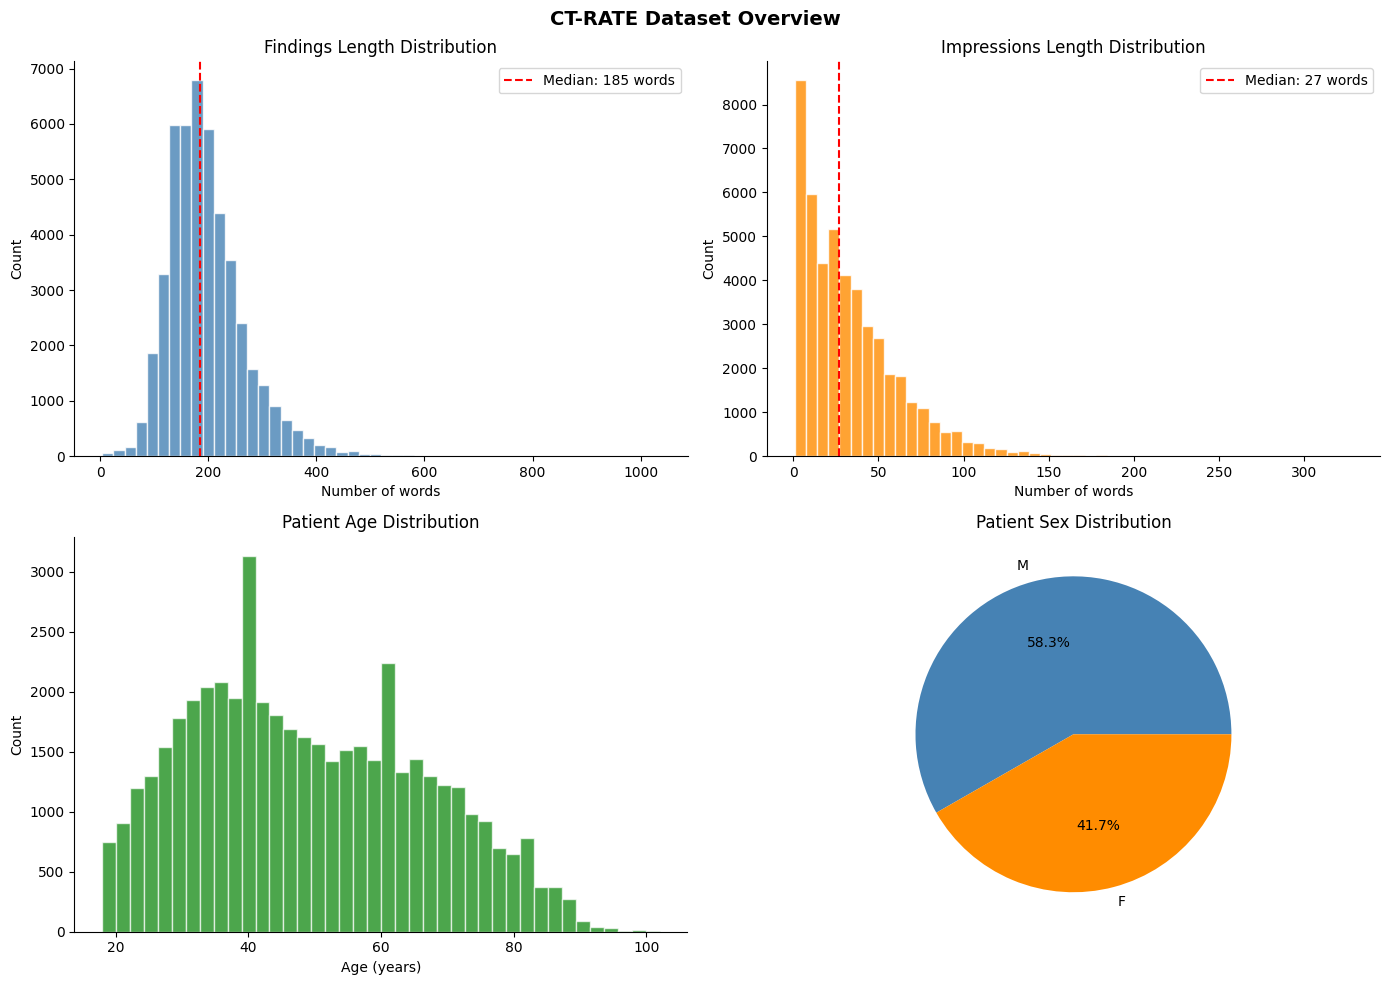

In [10]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CT-RATE Dataset Overview', fontsize=14, fontweight='bold')

# findings length distribution
ax = axes[0, 0]
ax.hist(df_combined['findings_len'], bins=50,
        color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(df_combined['findings_len'].median(), color='red',
           linestyle='--', label=f"Median: {df_combined['findings_len'].median():.0f} words")
ax.set_title('Findings Length Distribution')
ax.set_xlabel('Number of words')
ax.set_ylabel('Count')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# impressions length distribution
ax = axes[0, 1]
ax.hist(df_combined['impressions_len'], bins=50,
        color='darkorange', edgecolor='white', alpha=0.8)
ax.axvline(df_combined['impressions_len'].median(), color='red',
           linestyle='--', label=f"Median: {df_combined['impressions_len'].median():.0f} words")
ax.set_title('Impressions Length Distribution')
ax.set_xlabel('Number of words')
ax.set_ylabel('Count')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# age distribution
ax = axes[1, 0]
ax.hist(df_combined['PatientAge_num'].dropna(), bins=40,
        color='green', edgecolor='white', alpha=0.7)
ax.set_title('Patient Age Distribution')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# sex distribution
ax = axes[1, 1]
sex_counts = df_combined['PatientSex'].value_counts()
ax.pie(sex_counts.values, labels=sex_counts.index,
       autopct='%1.1f%%', colors=['steelblue', 'darkorange', 'gray'])
ax.set_title('Patient Sex Distribution')

plt.tight_layout()
plt.savefig('wp1_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Look at a sample report
sample_idx = 7  # choose 7 because this has clinical information
sample = df_combined.iloc[sample_idx]

print(f"Sample Report (index {sample_idx}):")
print(f"VolumeName: {sample['VolumeName']}")
print(f"Patient: {sample['PatientSex']}, {sample['PatientAge']}")
print(f"Study date: {sample['StudyDate']}")
print()

for field in ['ClinicalInformation_EN', 'Technique_EN', 'Findings_EN', 'Impressions_EN']:
    text = str(sample[field])
    print(f"--- {field} ({len(text.split())} words) ---")
    print(textwrap.fill(text, width=80)[:300] + "...\n")

Sample Report (index 7):
VolumeName: train_3_b_2.nii.gz
Patient: M, 073Y
Study date: 20221021

--- ClinicalInformation_EN (5 words) ---
Chronic renal failure, weakness, fatigue....

--- Technique_EN (13 words) ---
Sections were taken without contrast medium and reconstructions were made at the
workstation....

--- Findings_EN (304 words) ---
Central venous catheter is seen on the right. The catheter terminates in the
right atrium. Heart contour and size are normal. There are atheromatous plaques
in the aorta and coronary arteries. The widths of the mediastinal main vascular
structures are normal. Pericardial effusion was not detected. T...

--- Impressions_EN (63 words) ---
 Chronic renal failure in follow-up.  Bilateral pleural effusion, interlobular
septal thickenings and centriacinar nodules in both lungs (patient is
recommended to be evaluated for pulmonary edema).  Minor consolidations in the
right lung, which may again be compatible with pulmonary edema or pneumo...



## Key Fields for Downstream Analysis

The following fields are expected to be the most most relevant for WP2 (style analysis) and WP3 (normalization).

For report text analysis: `Findings_EN` and `Impressions_EN`, which contain the actual free-text radiology reports. `ClinicalInformation_EN` and `Technique_EN` provide additional context about the patient and scan protocol.

For patient-level queries: `PatientSex` and `PatientAge` are the relevant demographic fields. 
For study-level information, `StudyDate`, `SeriesDescription`, `CTDIvol` and `NumberofSlices`

NOTE: The labels dataset adds 18 binary abnormality columns.

`VolumeName` column is the key that links every report. 
Each patient can have multiple volumes due to different reconstruction kernels: This leads to duplicate reports which need to be handled via deduplication in WP2.

### Saving the Combined Dataset

In [12]:
# Drop the helper columns and save
df_save = df_combined.drop(columns=['findings_len', 'impressions_len', 'PatientAge_num'])

output_path = os.path.join(OUTPUT_DIR, "ctrate_train_combined.csv")
df_save.to_csv(output_path, index=False)

print(f"Dataset saved: {output_path}")
print(f"Shape: {df_save.shape}")

Dataset saved: ../data/ctrate_train_combined.csv
Shape: (47119, 66)
